# Per-Currency Discount Factor Extractor Demo

This notebook shows how to:

1. Extract explicit discount-factor pillars per currency from ORE artifacts.
2. Get both programmatic dict output and long-format DataFrame output.
3. Access the same payload through `native_xva_interface` session bridge.

The output is suitable for fast external curve-fitting workflows.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we import the canonical native_xva_interface from PythonIntegration.
repo_root = Path.cwd().resolve().parents[1]
python_integration = repo_root / "PythonIntegration"
if str(python_integration) not in sys.path:
    sys.path.insert(0, str(python_integration))

from py_ore_tools.ore_snapshot import (
    extract_discount_factors_by_currency,
    discount_factors_to_dataframe,
    extract_market_instruments_by_currency,
    extract_market_instruments_by_currency_from_quotes,
    fit_discount_curves_from_ore_market,
    fit_discount_curves_from_programmatic_quotes,
    fitted_curves_to_dataframe,
    quote_dicts_from_pairs,
)

from native_xva_interface import (
    FXForward,
    FixingsData,
    MarketData,
    MarketQuote,
    Portfolio,
    SourceMeta,
    Trade,
    XVAConfig,
    XVAEngine,
    XVASnapshot,
)

## How `native_xva_interface` works here (explicit architecture)

This notebook now has **two entry paths** that share one extraction contract.

### 1) Direct path (`py_ore_tools`)

- You call `extract_discount_factors_by_currency(...)` or `fit_discount_curves_from_ore_market(...)` directly.
- These functions parse ORE input/output files and return JSON/DataFrame payloads.

### 2) Bridge path (`native_xva_interface`)

- You create a `XVASession` from a snapshot.
- You call `session.extract_discount_factors_by_currency(...)`.
- Internally, `native_xva_interface` **bridges** into `py_ore_tools.ore_snapshot` and reuses the same extractor implementation.
- Result: same payload shape, so downstream code is identical.

### What `native_xva_interface` does vs does not do

- **Does:**
  - gives a runtime/session API (`XVAEngine` / `XVASession`)
  - lets you keep extraction close to existing in-engine workflows
  - resolves `ore_xml_path` from snapshot metadata when available
- **Does not (in this bridge):**
  - re-implement curve fitting logic
  - maintain a separate fitter implementation

### Why this split is useful

- `py_ore_tools` remains the **single source of truth** for extraction/fitting logic.
- `native_xva_interface` provides **integration ergonomics** (session-based access) without duplication.
- External fitters consume one stable contract regardless of call path.

### Data flow in this notebook

1. Read ORE files (`ore.xml`, `market_data`, `todaysmarket`, `curves.csv`)
2. Build per-ccy instruments (optional) and/or extract per-ccy DFs
3. Fit curve nodes (`weighted` or `bootstrap`; sparse or dense grid)
4. Emit JSON/DataFrame with `times`, `dfs`, `zero_rates`, `calendar_dates`
5. Plot / audit / export

In [2]:
# Sanity check: show which native_xva_interface is imported and bridge availability
import inspect
import native_xva_interface as nx

print("native_xva_interface module:", nx.__file__)
print("XVASession has DF bridge:", hasattr(nx.XVASession, "extract_discount_factors_by_currency"))

if hasattr(nx.XVASession, "extract_discount_factors_by_currency"):
    src = inspect.getsource(nx.XVASession.extract_discount_factors_by_currency)
    print("\nBridge method source (first lines):")
    print("\n".join(src.splitlines()[:12]))

native_xva_interface module: /Users/gordonlee/Documents/Engine/PythonIntegration/native_xva_interface/__init__.py
XVASession has DF bridge: True

Bridge method source (first lines):
    def extract_discount_factors_by_currency(
        self,
        ore_xml_path: Optional[str] = None,
        configuration_id: Optional[str] = None,
    ) -> Dict[str, Dict[str, object]]:
        """Bridge to PythonOreRunner per-currency DF extractor contract."""
        resolved_ore_xml = ore_xml_path or self._snapshot_ore_xml_path()
        if not resolved_ore_xml:
            raise EngineRunError(
                "No ore_xml_path provided and snapshot has no config source path. "
                "Pass ore_xml_path explicitly."
            )


In [3]:
# Default ORE input path (adjust if needed)
repo_root = Path.cwd().resolve().parents[1]
ore_xml = repo_root / "Examples" / "Exposure" / "Input" / "ore_measure_lgm.xml"

# Use a known-valid market configuration for this sample dataset.
# You can set this to None to rely on auto-detection if your ORE input supports it.
configuration_id = "libor"

print(f"ORE XML: {ore_xml}")
print(f"Exists: {ore_xml.exists()}")
print(f"configuration_id: {configuration_id}")

ORE XML: /Users/gordonlee/Documents/Engine/Examples/Exposure/Input/ore_measure_lgm.xml
Exists: True
configuration_id: libor


In [4]:
# 1) Direct extractor API (dict payload)
payload = extract_discount_factors_by_currency(
    ore_xml_path=ore_xml,
    configuration_id=configuration_id,
)

print(f"Currencies extracted: {sorted(payload.keys())}")
print(json.dumps({k: {x: payload[k][x] for x in ('curve_id', 'source_column', 'asof_date')} for k in sorted(payload)}, indent=2))

Currencies extracted: ['CHF', 'EUR', 'GBP', 'JPY', 'USD']
{
  "CHF": {
    "curve_id": "Yield/CHF/CHF6M",
    "source_column": "CHF-LIBOR-6M",
    "asof_date": "2016-02-05"
  },
  "EUR": {
    "curve_id": "Yield/EUR/EUR6M",
    "source_column": "EUR-EURIBOR-6M",
    "asof_date": "2016-02-05"
  },
  "GBP": {
    "curve_id": "Yield/GBP/GBP6M",
    "source_column": "GBP-LIBOR-6M",
    "asof_date": "2016-02-05"
  },
  "JPY": {
    "curve_id": "Yield/JPY/JPY6M",
    "source_column": "JPY-LIBOR-6M",
    "asof_date": "2016-02-05"
  },
  "USD": {
    "curve_id": "Yield/USD/USD3M",
    "source_column": "USD-LIBOR-3M",
    "asof_date": "2016-02-05"
  }
}


In [5]:
# 2) DataFrame adapter (long format)
df = discount_factors_to_dataframe(payload)

print(df.head(12))
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

    ccy         curve_id      time        df   asof_date source_column
0   CHF  Yield/CHF/CHF6M  0.000000  1.000000  2016-02-05  CHF-LIBOR-6M
1   CHF  Yield/CHF/CHF6M  0.079452  1.001495  2016-02-05  CHF-LIBOR-6M
2   CHF  Yield/CHF/CHF6M  0.161644  1.002172  2016-02-05  CHF-LIBOR-6M
3   CHF  Yield/CHF/CHF6M  0.249315  1.002876  2016-02-05  CHF-LIBOR-6M
4   CHF  Yield/CHF/CHF6M  0.328767  1.003514  2016-02-05  CHF-LIBOR-6M
5   CHF  Yield/CHF/CHF6M  0.413699  1.004197  2016-02-05  CHF-LIBOR-6M
6   CHF  Yield/CHF/CHF6M  0.498630  1.004887  2016-02-05  CHF-LIBOR-6M
7   CHF  Yield/CHF/CHF6M  0.580822  1.005761  2016-02-05  CHF-LIBOR-6M
8   CHF  Yield/CHF/CHF6M  0.671233  1.006649  2016-02-05  CHF-LIBOR-6M
9   CHF  Yield/CHF/CHF6M  0.747945  1.007264  2016-02-05  CHF-LIBOR-6M
10  CHF  Yield/CHF/CHF6M  0.832877  1.008042  2016-02-05  CHF-LIBOR-6M
11  CHF  Yield/CHF/CHF6M  0.920548  1.008786  2016-02-05  CHF-LIBOR-6M
Rows: 1,200
Columns: ['ccy', 'curve_id', 'time', 'df', 'asof_date', 'source_c

In [6]:
# 3) Optional: native_xva_interface session bridge
# Build a tiny snapshot and call the bridge API from session.
snapshot = XVASnapshot(
    market=MarketData(asof="2026-03-08"),
    fixings=FixingsData(),
    portfolio=Portfolio(
        trades=(
            Trade(
                trade_id="T1",
                counterparty="CP_A",
                netting_set="NS1",
                trade_type="FxForward",
                product=FXForward(pair="EURUSD", notional=1_000_000, strike=1.1, maturity_years=1.0),
            ),
        )
    ),
    config=XVAConfig(
        asof="2026-03-08",
        base_currency="EUR",
        analytics=("CVA",),
        source_meta=SourceMeta(origin="file", path=str(ore_xml)),
    ),
)

session = XVAEngine().create_session(snapshot)
bridge_payload = session.extract_discount_factors_by_currency(
    configuration_id=configuration_id,
)
bridge_df = session.discount_factors_to_dataframe(bridge_payload)

print(f"Bridge currencies: {sorted(bridge_payload.keys())}")
print(bridge_df.head(8))

Bridge currencies: ['CHF', 'EUR', 'GBP', 'JPY', 'USD']
   ccy         curve_id      time        df   asof_date source_column
0  CHF  Yield/CHF/CHF6M  0.000000  1.000000  2016-02-05  CHF-LIBOR-6M
1  CHF  Yield/CHF/CHF6M  0.079452  1.001495  2016-02-05  CHF-LIBOR-6M
2  CHF  Yield/CHF/CHF6M  0.161644  1.002172  2016-02-05  CHF-LIBOR-6M
3  CHF  Yield/CHF/CHF6M  0.249315  1.002876  2016-02-05  CHF-LIBOR-6M
4  CHF  Yield/CHF/CHF6M  0.328767  1.003514  2016-02-05  CHF-LIBOR-6M
5  CHF  Yield/CHF/CHF6M  0.413699  1.004197  2016-02-05  CHF-LIBOR-6M
6  CHF  Yield/CHF/CHF6M  0.498630  1.004887  2016-02-05  CHF-LIBOR-6M
7  CHF  Yield/CHF/CHF6M  0.580822  1.005761  2016-02-05  CHF-LIBOR-6M


In [7]:
# 4) Example export for external fitter
out_dir = Path.cwd() / "parity_artifacts" / "df_extractor_demo"
out_dir.mkdir(parents=True, exist_ok=True)

json_path = out_dir / "discount_factors_by_ccy.json"
csv_path = out_dir / "discount_factors_by_ccy_long.csv"

json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
df.to_csv(csv_path, index=False)

print(f"Wrote: {json_path}")
print(f"Wrote: {csv_path}")
print("Note: fitted sparse/dense exports are shown later in this notebook.")

Wrote: /Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/parity_artifacts/df_extractor_demo/discount_factors_by_ccy.json
Wrote: /Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/parity_artifacts/df_extractor_demo/discount_factors_by_ccy_long.csv
Note: fitted sparse/dense exports are shown later in this notebook.


## Graphical view of extracted curves

The plots below make it easier to compare curve shapes across currencies and spot inconsistencies quickly before passing data to an external fitter.

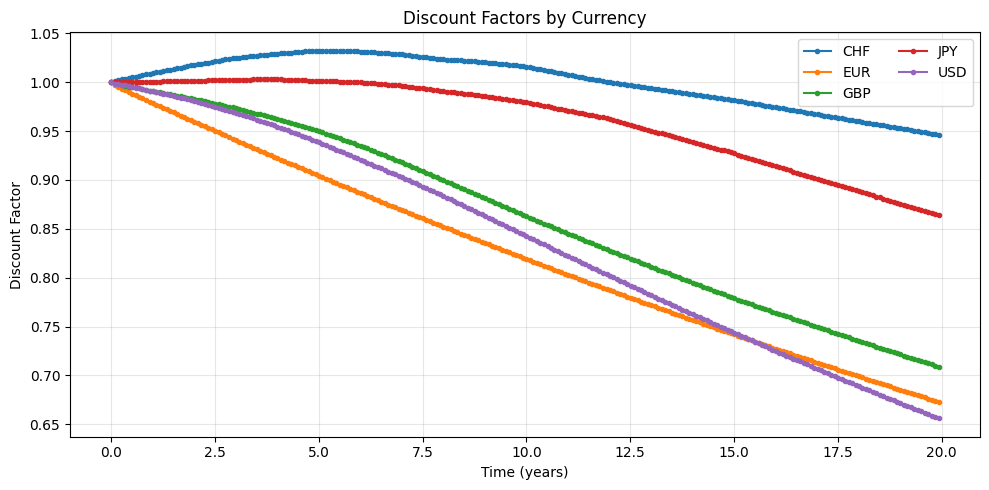

In [8]:
# A) Discount factors vs time (all currencies)
fig, ax = plt.subplots(figsize=(10, 5))
for ccy, grp in df.groupby("ccy"):
    g = grp.sort_values("time")
    ax.plot(g["time"], g["df"], marker="o", markersize=3, linewidth=1.5, label=ccy)

ax.set_title("Discount Factors by Currency")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Discount Factor")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

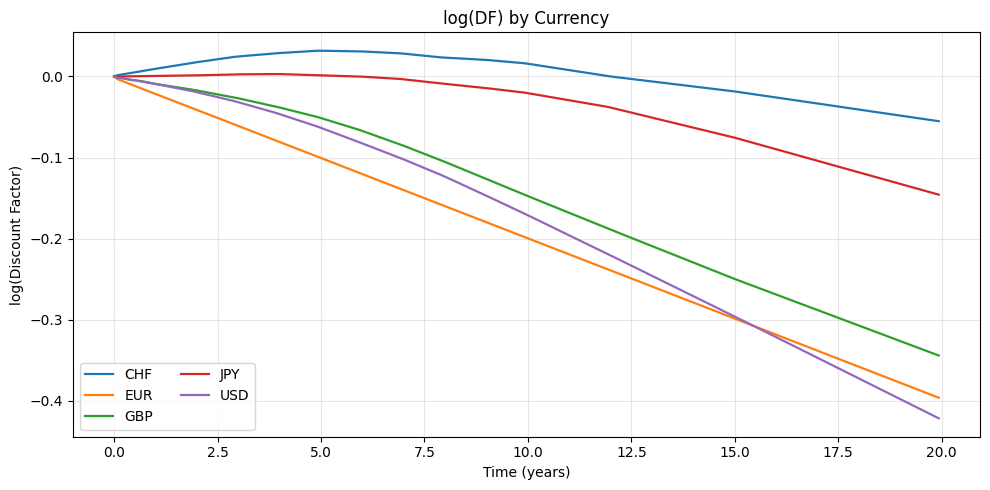

In [9]:
# B) Log-DF view (useful for comparing long-end slope)
fig, ax = plt.subplots(figsize=(10, 5))
for ccy, grp in df.groupby("ccy"):
    g = grp.sort_values("time")
    safe_df = np.clip(g["df"].to_numpy(dtype=float), 1.0e-12, None)
    ax.plot(g["time"], np.log(safe_df), linewidth=1.6, label=ccy)

ax.set_title("log(DF) by Currency")
ax.set_xlabel("Time (years)")
ax.set_ylabel("log(Discount Factor)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

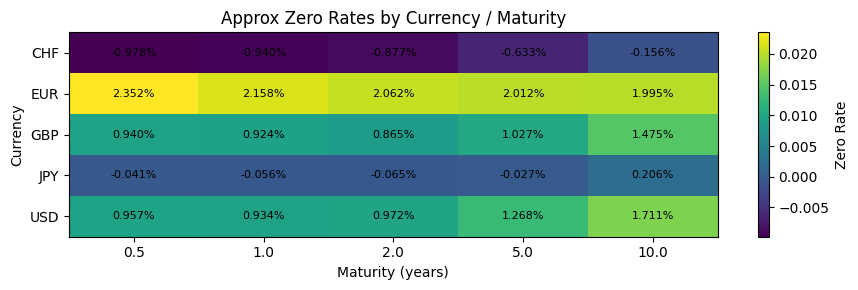

,ccy,asof_date,maturity,calendar_date,zero_rate
0,CHF,2016-02-05,0.5,2016-08-05,-0.009780
1,CHF,2016-02-05,1.0,2017-02-04,-0.009400
2,CHF,2016-02-05,2.0,2018-02-04,-0.008770
3,CHF,2016-02-05,5.0,2021-02-03,-0.006335
4,CHF,2016-02-05,10.0,2026-02-02,-0.001564
5,EUR,2016-02-05,0.5,2016-08-05,0.023522
6,EUR,2016-02-05,1.0,2017-02-04,0.021580
7,EUR,2016-02-05,2.0,2018-02-04,0.020615
8,EUR,2016-02-05,5.0,2021-02-03,0.020116
9,EUR,2016-02-05,10.0,2026-02-02,0.019953


In [10]:
# C) Approx zero-rate summary heatmap at selected maturities
#    + calendar dates for each interpolated maturity
selected_maturities = np.array([0.5, 1.0, 2.0, 5.0, 10.0], dtype=float)
rows = []
for ccy, grp in df.groupby("ccy"):
    g = grp.sort_values("time")
    t = g["time"].to_numpy(dtype=float)
    p = np.clip(g["df"].to_numpy(dtype=float), 1.0e-12, None)

    # One as-of date per currency payload in this demo.
    asof = pd.to_datetime(g["asof_date"].iloc[0])

    for m in selected_maturities:
        p_m = float(np.interp(m, t, p, left=p[0], right=p[-1]))
        z_m = -np.log(p_m) / max(m, 1.0e-12)
        cal_date = asof + pd.to_timedelta(int(round(m * 365.0)), unit="D")
        rows.append(
            {
                "ccy": ccy,
                "asof_date": asof.date().isoformat(),
                "maturity": m,
                "calendar_date": cal_date.date().isoformat(),
                "zero_rate": z_m,
            }
        )

zdf = pd.DataFrame(rows)
pivot = zdf.pivot(index="ccy", columns="maturity", values="zero_rate").sort_index()

fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(pivot))))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Approx Zero Rates by Currency / Maturity")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Currency")
ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)), labels=list(pivot.index))

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3%}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Zero Rate")
plt.tight_layout()
plt.show()

# Interpolated points with explicit calendar date
zdf.sort_values(["ccy", "maturity"]).reset_index(drop=True)

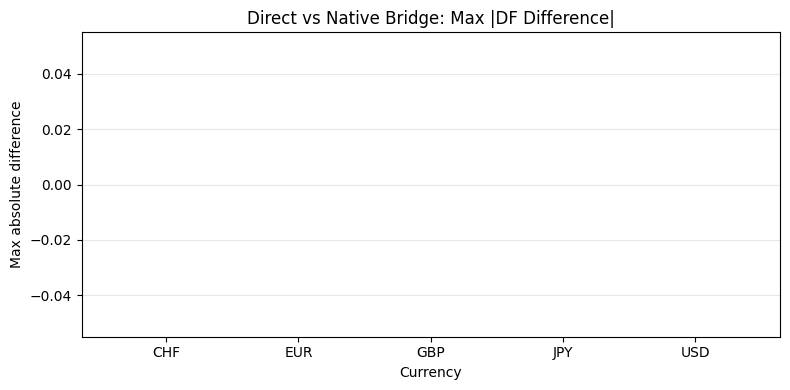

,ccy,abs_diff
0,CHF,0.0
1,EUR,0.0
2,GBP,0.0
3,JPY,0.0
4,USD,0.0


In [11]:
# D) Quick consistency check: direct extractor vs native bridge
# (max absolute DF diff by currency after inner join on (ccy, time)).
left = df.rename(columns={"df": "df_direct"})
right = bridge_df.rename(columns={"df": "df_bridge"})
cmp_df = left.merge(right[["ccy", "time", "df_bridge"]], on=["ccy", "time"], how="inner")

summary = (
    cmp_df.assign(abs_diff=(cmp_df["df_direct"] - cmp_df["df_bridge"]).abs())
    .groupby("ccy", as_index=False)["abs_diff"]
    .max()
    .sort_values("abs_diff", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary["ccy"], summary["abs_diff"])
ax.set_title("Direct vs Native Bridge: Max |DF Difference|")
ax.set_xlabel("Currency")
ax.set_ylabel("Max absolute difference")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

summary

## Input vs Output audit

This section makes it explicit:

- **What went in**: instrument/trade counts from ORE `portfolio.xml`.
- **What came out**: per-currency DF curve counts and pillar counts from extractor output.

In [12]:
import xml.etree.ElementTree as ET

# Resolve portfolio.xml from ore.xml setup
ore_root = ET.parse(ore_xml).getroot()
setup_params = {
    n.attrib.get("name", ""): (n.text or "").strip()
    for n in ore_root.findall("./Setup/Parameter")
}
base = ore_xml.parent
portfolio_rel = setup_params.get("portfolioFile", "portfolio.xml")
portfolio_xml = (base / portfolio_rel).resolve()

portfolio_root = ET.parse(portfolio_xml).getroot()
trades = portfolio_root.findall("./Trade")

trade_rows = []
for t in trades:
    trade_id = t.attrib.get("id", "")
    trade_type = (t.findtext("./TradeType") or "Unknown").strip()
    cpty = (t.findtext("./Envelope/CounterParty") or "UNKNOWN").strip()
    ns = (t.findtext("./Envelope/NettingSetId") or cpty).strip()

    # Try common currency paths for quick audit visibility.
    ccy = (
        (t.findtext(".//SwapData/LegData/Currency") or "").strip()
        or (t.findtext(".//FxForwardData/BoughtCurrency") or "").strip()
        or "N/A"
    )

    trade_rows.append(
        {
            "trade_id": trade_id,
            "trade_type": trade_type,
            "counterparty": cpty,
            "netting_set": ns,
            "currency_hint": ccy,
        }
    )

trades_df = pd.DataFrame(trade_rows)

print(f"Input portfolio file: {portfolio_xml}")
print(f"Total input trades: {len(trades_df):,}")

display(trades_df.head(20))

display(
    trades_df.groupby("trade_type", as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

display(
    trades_df.groupby(["trade_type", "currency_hint"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)

Input portfolio file: /Users/gordonlee/Documents/Engine/Examples/Exposure/Input/portfolio_singleswap.xml
Total input trades: 1


,trade_id,trade_type,counterparty,netting_set,currency_hint
0,Swap_20,Swap,CPTY_A,CPTY_A,EUR


,trade_type,count
0,Swap,1


,trade_type,currency_hint,count
0,Swap,EUR,1


In [13]:
# Output audit: what the extractor produced
output_rows = []
for ccy, item in payload.items():
    times = item.get("times", [])
    dfs = item.get("dfs", [])
    cal_dates = item.get("calendar_dates", [])
    output_rows.append(
        {
            "ccy": ccy,
            "curve_id": item.get("curve_id", ""),
            "source_column": item.get("source_column", ""),
            "asof_date": item.get("asof_date", ""),
            "n_times": len(times),
            "n_dfs": len(dfs),
            "n_calendar_dates": len(cal_dates),
            "first_time": float(times[0]) if times else np.nan,
            "last_time": float(times[-1]) if times else np.nan,
            "first_calendar_date": cal_dates[0] if cal_dates else "",
            "last_calendar_date": cal_dates[-1] if cal_dates else "",
        }
    )

output_audit_df = pd.DataFrame(output_rows).sort_values("ccy").reset_index(drop=True)

print(f"Total output currencies: {len(output_audit_df):,}")
print(f"Total output DF points (long format rows): {len(df):,}")

display(output_audit_df)

# Optional compact mapping: input trade currencies vs output curve currencies
input_ccys = sorted({c for c in trades_df["currency_hint"].dropna().astype(str) if c and c != "N/A"})
output_ccys = sorted(output_audit_df["ccy"].tolist())

print("Input trade currencies (hint):", input_ccys)
print("Output curve currencies:", output_ccys)
print("Missing in output:", sorted(set(input_ccys) - set(output_ccys)))
print("Extra in output:", sorted(set(output_ccys) - set(input_ccys)))

Total output currencies: 5
Total output DF points (long format rows): 1,200


,ccy,curve_id,source_column,asof_date,n_times,n_dfs,n_calendar_dates,first_time,last_time,first_calendar_date,last_calendar_date
0,CHF,Yield/CHF/CHF6M,CHF-LIBOR-6M,2016-02-05,240,240,240,0.0,19.928767,2016-02-05,2036-01-05
1,EUR,Yield/EUR/EUR6M,EUR-EURIBOR-6M,2016-02-05,240,240,240,0.0,19.928767,2016-02-05,2036-01-05
2,GBP,Yield/GBP/GBP6M,GBP-LIBOR-6M,2016-02-05,240,240,240,0.0,19.928767,2016-02-05,2036-01-05
3,JPY,Yield/JPY/JPY6M,JPY-LIBOR-6M,2016-02-05,240,240,240,0.0,19.928767,2016-02-05,2036-01-05
4,USD,Yield/USD/USD3M,USD-LIBOR-3M,2016-02-05,240,240,240,0.0,19.928767,2016-02-05,2036-01-05


Input trade currencies (hint): ['EUR']
Output curve currencies: ['CHF', 'EUR', 'GBP', 'JPY', 'USD']
Missing in output: []
Extra in output: ['CHF', 'GBP', 'JPY', 'USD']


## True instrument-in -> curve-out flow

This is the quick external fitter path:

- Parse market instruments per currency from ORE market data.
- Fit a fast discount curve per currency.
- Inspect exactly how many instruments went in and how many fitted points came out.

In [14]:
# 5) Instrument extraction from ORE market data
inst_by_ccy = extract_market_instruments_by_currency(
    ore_xml_path=ore_xml,
    instrument_types=("ZERO", "MM", "IR_SWAP"),
)

inst_audit = pd.DataFrame(
    [
        {
            "ccy": ccy,
            "asof_date": p["asof_date"],
            "instrument_count": p["instrument_count"],
            "counts_by_type": json.dumps(p["instrument_counts_by_type"], sort_keys=True),
        }
        for ccy, p in sorted(inst_by_ccy.items())
    ]
)

display(inst_audit)

# Optional: show first few instruments per currency
for ccy, p in sorted(inst_by_ccy.items()):
    print(f"\n{ccy} instruments (first 8):")
    display(pd.DataFrame(p["instruments"]).head(8))

,ccy,asof_date,instrument_count,counts_by_type
0,CHF,2016-02-05,63,"{""IR_SWAP"": 53, ""MM"": 10}"
1,EUR,2016-02-05,137,"{""IR_SWAP"": 110, ""MM"": 17, ""ZERO"": 10}"
2,GBP,2016-02-05,64,"{""IR_SWAP"": 55, ""MM"": 9}"
3,JPY,2016-02-05,43,"{""IR_SWAP"": 36, ""MM"": 7}"
4,SEK,2016-02-05,22,"{""IR_SWAP"": 15, ""MM"": 7}"
5,USD,2016-02-05,54,"{""IR_SWAP"": 45, ""MM"": 9}"



CHF instruments (first 8):


,instrument_type,quote_key,quote_value,tenor,maturity,index,asof_date
0,MM,MM/RATE/CHF/0D/1D,-0.007369,1D,0.002740,0D,2016-02-05
1,MM,MM/RATE/CHF/0D/2D,-0.007494,2D,0.005479,0D,2016-02-05
2,MM,MM/RATE/CHF/2D/3D,-0.007403,3D,0.008219,2D,2016-02-05
3,MM,MM/RATE/CHF/2D/1W,-0.007215,1W,0.019231,2D,2016-02-05
4,MM,MM/RATE/CHF/2D/2W,-0.007464,2W,0.038462,2D,2016-02-05
5,MM,MM/RATE/CHF/2D/3W,-0.007724,3W,0.057692,2D,2016-02-05
6,IR_SWAP,IR_SWAP/RATE/CHF/2D/1D/1M,-0.007465,1M,0.083333,2D,2016-02-05
7,MM,MM/RATE/CHF/2D/1M,-0.009297,1M,0.083333,2D,2016-02-05



EUR instruments (first 8):


,instrument_type,quote_key,quote_value,tenor,maturity,index,asof_date
0,IR_SWAP,IR_SWAP/RATE/EUR/0D/1D/1D,0.02,1D,0.002740,0D,2016-02-05
1,MM,MM/RATE/EUR/0D/1D,0.02,1D,0.002740,0D,2016-02-05
2,IR_SWAP,IR_SWAP/RATE/EUR/0D/1D/2D,0.02,2D,0.005479,0D,2016-02-05
3,MM,MM/RATE/EUR/0D/2D,0.02,2D,0.005479,0D,2016-02-05
4,IR_SWAP,IR_SWAP/RATE/EUR/2D/1D/3D,0.02,3D,0.008219,2D,2016-02-05
5,IR_SWAP,IR_SWAP/RATE/EUR/2D/1D/1W,0.02,1W,0.019231,2D,2016-02-05
6,MM,MM/RATE/EUR/2D/1W,0.02,1W,0.019231,2D,2016-02-05
7,IR_SWAP,IR_SWAP/RATE/EUR/2D/1D/2W,0.02,2W,0.038462,2D,2016-02-05


...

,instrument_type,quote_key,quote_value,tenor,maturity,index,asof_date
0,IR_SWAP,IR_SWAP/RATE/JPY/0D/1D/2D,-0.000579,2D,0.005479,0D,2016-02-05
1,MM,MM/RATE/JPY/0D/2D,-0.000664,2D,0.005479,0D,2016-02-05
2,MM,MM/RATE/JPY/2D/3D,-0.002130,3D,0.008219,2D,2016-02-05
3,MM,MM/RATE/JPY/2D/1W,-0.000603,1W,0.019231,2D,2016-02-05
4,MM,MM/RATE/JPY/2D/2W,-0.002159,2W,0.038462,2D,2016-02-05
5,IR_SWAP,IR_SWAP/RATE/JPY/2D/1D/1M,0.000660,1M,0.083333,2D,2016-02-05
6,MM,MM/RATE/JPY/2D/1M,-0.003899,1M,0.083333,2D,2016-02-05
7,IR_SWAP,IR_SWAP/RATE/JPY/2D/1D/2M,0.000459,2M,0.166667,2D,2016-02-05



SEK instruments (first 8):


,instrument_type,quote_key,quote_value,tenor,maturity,index,asof_date
0,MM,MM/RATE/SEK/0D/1D,-0.008371,1D,0.002740,0D,2016-02-05
1,MM,MM/RATE/SEK/0D/2D,-0.005952,2D,0.005479,0D,2016-02-05
2,MM,MM/RATE/SEK/2D/1W,-0.006089,1W,0.019231,2D,2016-02-05
3,MM,MM/RATE/SEK/2D/1M,-0.006708,1M,0.083333,2D,2016-02-05
4,MM,MM/RATE/SEK/2D/2M,-0.006028,2M,0.166667,2D,2016-02-05
5,MM,MM/RATE/SEK/2D/3M,-0.005703,3M,0.250000,2D,2016-02-05
6,MM,MM/RATE/SEK/2D/6M,-0.004315,6M,0.500000,2D,2016-02-05
7,IR_SWAP,IR_SWAP/RATE/SEK/2D/6M/1Y,-0.004964,1Y,1.000000,2D,2016-02-05



USD instruments (first 8):


,instrument_type,quote_key,quote_value,tenor,maturity,index,asof_date
0,IR_SWAP,IR_SWAP/RATE/USD/0D/1D/1D,0.004502,1D,0.002740,0D,2016-02-05
1,MM,MM/RATE/USD/0D/1D,0.004480,1D,0.002740,0D,2016-02-05
2,IR_SWAP,IR_SWAP/RATE/USD/0D/1D/2D,0.005616,2D,0.005479,0D,2016-02-05
3,MM,MM/RATE/USD/0D/2D,0.005598,2D,0.005479,0D,2016-02-05
4,IR_SWAP,IR_SWAP/RATE/USD/2D/1D/1W,0.004473,1W,0.019231,2D,2016-02-05
5,MM,MM/RATE/USD/2D/1W,0.005809,1W,0.019231,2D,2016-02-05
6,IR_SWAP,IR_SWAP/RATE/USD/2D/1D/2W,0.004587,2W,0.038462,2D,2016-02-05
7,MM,MM/RATE/USD/2D/2W,0.006034,2W,0.038462,2D,2016-02-05


In [15]:
# 6) Fit curves from those instruments (weighted + bootstrap, sparse + dense)
fitted = fit_discount_curves_from_ore_market(
    ore_xml_path=ore_xml,
    instrument_types=("ZERO", "MM", "IR_SWAP"),
    fit_method="weighted_zero_logdf_v1",
    fit_grid_mode="instrument",
)
fitted_df = fitted_curves_to_dataframe(fitted)

fitted_dense = fit_discount_curves_from_ore_market(
    ore_xml_path=ore_xml,
    instrument_types=("ZERO", "MM", "IR_SWAP"),
    fit_method="weighted_zero_logdf_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)
fitted_dense_df = fitted_curves_to_dataframe(fitted_dense)

fitted_bootstrap = fit_discount_curves_from_ore_market(
    ore_xml_path=ore_xml,
    instrument_types=("ZERO", "MM", "IR_SWAP"),
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="instrument",
)
fitted_bootstrap_df = fitted_curves_to_dataframe(fitted_bootstrap)

fitted_bootstrap_dense = fit_discount_curves_from_ore_market(
    ore_xml_path=ore_xml,
    instrument_types=("ZERO", "MM", "IR_SWAP"),
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)
fitted_bootstrap_dense_df = fitted_curves_to_dataframe(fitted_bootstrap_dense)

fit_audit = pd.DataFrame(
    [
        {
            "ccy": ccy,
            "instrument_count": fitted[ccy]["instrument_count"],
            "weighted_sparse_points": fitted[ccy]["fit_points_count"],
            "weighted_dense_points": fitted_dense[ccy]["fit_points_count"],
            "bootstrap_sparse_points": fitted_bootstrap[ccy]["fit_points_count"],
            "bootstrap_dense_points": fitted_bootstrap_dense[ccy]["fit_points_count"],
            "dense_step_years": fitted_dense[ccy]["dense_step_years"],
        }
        for ccy in sorted(fitted.keys())
    ]
)

display(fit_audit)
print("Weighted sparse rows:", len(fitted_df))
print("Weighted dense rows:", len(fitted_dense_df))
print("Bootstrap sparse rows:", len(fitted_bootstrap_df))
print("Bootstrap dense rows:", len(fitted_bootstrap_dense_df))
display(fitted_bootstrap_dense_df.head(20))

,ccy,instrument_count,weighted_sparse_points,weighted_dense_points,bootstrap_sparse_points,bootstrap_dense_points,dense_step_years
0,CHF,63,33,121,33,121,0.25
1,EUR,137,50,201,50,201,0.25
2,GBP,64,39,281,39,281,0.25
3,JPY,43,29,161,29,161,0.25
4,SEK,22,23,121,23,121,0.25
5,USD,54,34,201,34,201,0.25


Weighted sparse rows: 208
Weighted dense rows: 1086
Bootstrap sparse rows: 208
Bootstrap dense rows: 1086


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method,instrument_count
0,CHF,2016-02-05,0.00,2016-02-05,1.0,0.0,bootstrap_mm_irs_v1,63
1,CHF,2016-02-05,0.25,2016-05-06,1.0,-0.0,bootstrap_mm_irs_v1,63
2,CHF,2016-02-05,0.50,2016-08-05,1.0,-0.0,bootstrap_mm_irs_v1,63
3,CHF,2016-02-05,0.75,2016-11-05,1.0,-0.0,bootstrap_mm_irs_v1,63
4,CHF,2016-02-05,1.00,2017-02-04,1.0,-0.0,bootstrap_mm_irs_v1,63
5,CHF,2016-02-05,1.25,2017-05-06,1.0,0.0,bootstrap_mm_irs_v1,63
6,CHF,2016-02-05,1.50,2017-08-06,1.0,0.0,bootstrap_mm_irs_v1,63
7,CHF,2016-02-05,1.75,2017-11-05,1.0,0.0,bootstrap_mm_irs_v1,63
8,CHF,2016-02-05,2.00,2018-02-04,1.0,-0.0,bootstrap_mm_irs_v1,63
9,CHF,2016-02-05,2.25,2018-05-06,1.0,0.0,bootstrap_mm_irs_v1,63


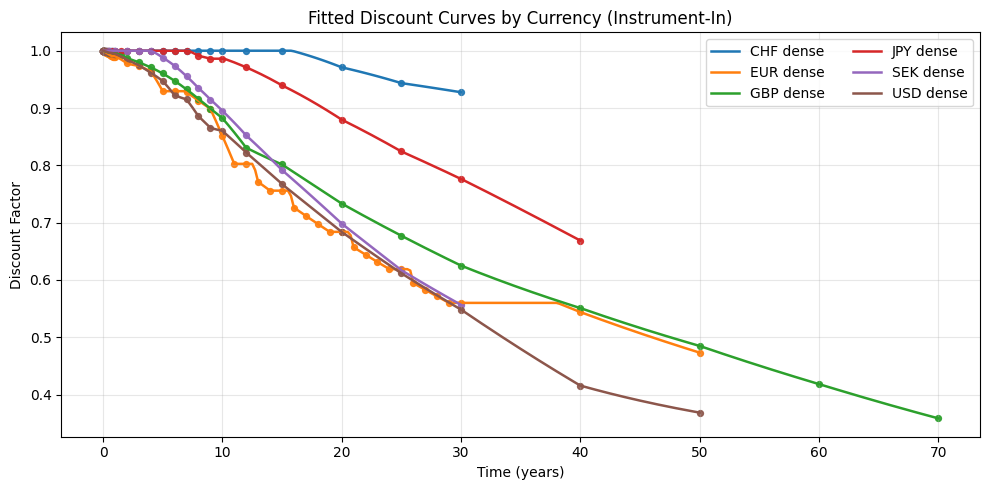

In [16]:
# 7) Graph fitted discount curves (sparse points + dense line)
fig, ax = plt.subplots(figsize=(10, 5))
for ccy in sorted(fitted.keys()):
    sparse = fitted_df[fitted_df["ccy"] == ccy].sort_values("time")
    dense = fitted_dense_df[fitted_dense_df["ccy"] == ccy].sort_values("time")
    ax.plot(dense["time"], dense["df"], linewidth=1.8, label=f"{ccy} dense")
    ax.scatter(sparse["time"], sparse["df"], s=18, alpha=0.9)

ax.set_title("Fitted Discount Curves by Currency (Instrument-In)")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Discount Factor")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## Purely programmatic version (no XML)

This section demonstrates the same curve fitting flow using only in-memory quotes.

- No `ore.xml`
- No file parsing
- Same output contract (`times`, `dfs`, `zero_rates`, `calendar_dates`)

In [23]:
# 8) Build programmatic quotes directly in code
# You can use either dicts or lightweight (key, value) tuples.
programmatic_quote_pairs = [
    # USD
    ("MM/RATE/USD/USD-LIBOR/1M", 0.0520),
    ("MM/RATE/USD/USD-LIBOR/3M", 0.0515),
    ("ZERO/RATE/USD/1Y", 0.0500),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/2Y", 0.0485),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/5Y", 0.0470),
    # EUR
    ("MM/RATE/EUR/EUR-EURIBOR/1M", 0.0310),
    ("ZERO/RATE/EUR/1Y", 0.0300),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/2Y", 0.0310),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/5Y", 0.0320),
]
programmatic_quotes = quote_dicts_from_pairs(programmatic_quote_pairs)
prog_asof = "2026-03-08"

prog_inst = extract_market_instruments_by_currency_from_quotes(
    asof_date=prog_asof,
    quotes=programmatic_quotes,
)

display(
    pd.DataFrame(
        [
            {
                "ccy": ccy,
                "instrument_count": p["instrument_count"],
                "counts_by_type": json.dumps(p["instrument_counts_by_type"], sort_keys=True),
            }
            for ccy, p in sorted(prog_inst.items())
        ]
    )
)

,ccy,instrument_count,counts_by_type
0,EUR,4,"{""IR_SWAP"": 2, ""MM"": 1, ""ZERO"": 1}"
1,USD,5,"{""IR_SWAP"": 2, ""MM"": 2, ""ZERO"": 1}"


In [24]:
# 9) Fit programmatic curves (bootstrap + dense grid)
prog_fitted = fit_discount_curves_from_programmatic_quotes(
    asof_date=prog_asof,
    quotes=programmatic_quotes,
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)
prog_fitted_df = fitted_curves_to_dataframe(prog_fitted)

display(
    pd.DataFrame(
        [
            {
                "ccy": ccy,
                "instrument_count": p["instrument_count"],
                "fit_points_count": p["fit_points_count"],
                "curve_method": p["curve_method"],
                "fit_grid_mode": p["fit_grid_mode"],
            }
            for ccy, p in sorted(prog_fitted.items())
        ]
    )
)
display(prog_fitted_df.head(20))

,ccy,instrument_count,fit_points_count,curve_method,fit_grid_mode
0,EUR,4,21,bootstrap_mm_irs_v1,dense
1,USD,5,21,bootstrap_mm_irs_v1,dense


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method,instrument_count
0,EUR,2026-03-08,0.00,2026-03-08,1.000000,0.000000,bootstrap_mm_irs_v1,4
1,EUR,2026-03-08,0.25,2026-06-07,0.992325,0.030818,bootstrap_mm_irs_v1,4
2,EUR,2026-03-08,0.50,2026-09-06,0.984843,0.030545,bootstrap_mm_irs_v1,4
3,EUR,2026-03-08,0.75,2026-12-07,0.977551,0.030273,bootstrap_mm_irs_v1,4
4,EUR,2026-03-08,1.00,2027-03-08,0.970446,0.030000,bootstrap_mm_irs_v1,4
5,EUR,2026-03-08,1.25,2027-06-07,0.963033,0.030134,bootstrap_mm_irs_v1,4
6,EUR,2026-03-08,1.50,2027-09-07,0.955612,0.030269,bootstrap_mm_irs_v1,4
7,EUR,2026-03-08,1.75,2027-12-07,0.948185,0.030403,bootstrap_mm_irs_v1,4
8,EUR,2026-03-08,2.00,2028-03-07,0.940753,0.030537,bootstrap_mm_irs_v1,4
9,EUR,2026-03-08,2.25,2028-06-06,0.933311,0.030674,bootstrap_mm_irs_v1,4


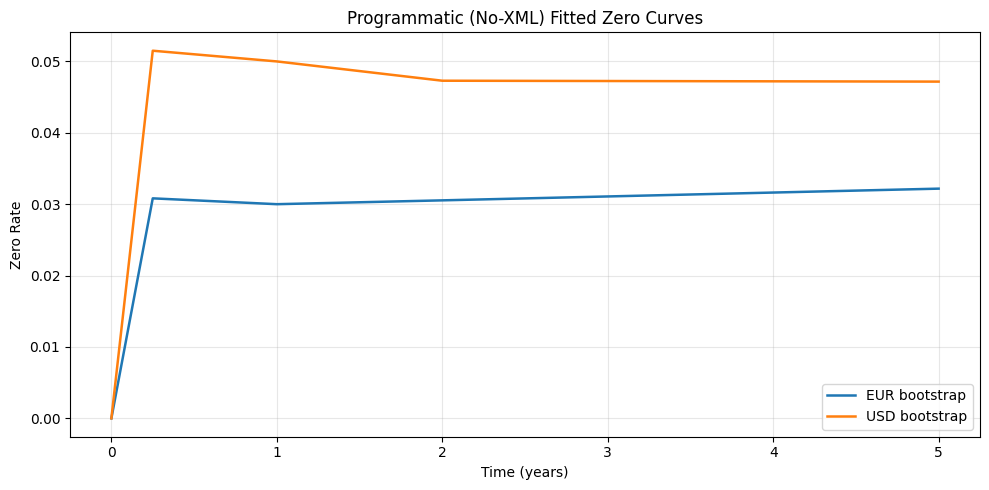

In [25]:
# 10) Plot programmatic zero curves
fig, ax = plt.subplots(figsize=(10, 5))
for ccy, grp in prog_fitted_df.groupby("ccy"):
    g = grp.sort_values("time")
    ax.plot(g["time"], g["zero_rate"], linewidth=1.8, label=f"{ccy} bootstrap")

ax.set_title("Programmatic (No-XML) Fitted Zero Curves")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Zero Rate")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# 11) Same no-XML flow via native_xva_interface session (programmatic bridge)
prog_snapshot = XVASnapshot(
    market=MarketData(
        asof=prog_asof,
        raw_quotes=tuple(
            MarketQuote(date=prog_asof, key=q["key"], value=float(q["value"]))
            for q in programmatic_quotes
        ),
    ),
    fixings=FixingsData(),
    portfolio=Portfolio(
        trades=(
            Trade(
                trade_id="DEMO_FX_1",
                counterparty="CP_A",
                netting_set="NS1",
                trade_type="FxForward",
                product=FXForward(pair="EURUSD", notional=1_000_000, strike=1.1, maturity_years=1.0),
            ),
        )
    ),
    config=XVAConfig(asof=prog_asof, base_currency="EUR", analytics=("CVA",)),
)
prog_session = XVAEngine().create_session(prog_snapshot)

prog_bridge_fitted = prog_session.fit_discount_curves_from_snapshot_market(
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)
prog_bridge_df = prog_session.fitted_curves_to_dataframe(prog_bridge_fitted)

print("Programmatic bridge currencies:", sorted(prog_bridge_fitted.keys()))
display(prog_bridge_df.head(20))

Programmatic bridge currencies: ['EUR', 'USD']


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method,instrument_count
0,EUR,2026-03-08,0.00,2026-03-08,1.000000,0.000000,bootstrap_mm_irs_v1,4
1,EUR,2026-03-08,0.25,2026-06-07,0.992325,0.030818,bootstrap_mm_irs_v1,4
2,EUR,2026-03-08,0.50,2026-09-06,0.984843,0.030545,bootstrap_mm_irs_v1,4
3,EUR,2026-03-08,0.75,2026-12-07,0.977551,0.030273,bootstrap_mm_irs_v1,4
4,EUR,2026-03-08,1.00,2027-03-08,0.970446,0.030000,bootstrap_mm_irs_v1,4
5,EUR,2026-03-08,1.25,2027-06-07,0.963033,0.030134,bootstrap_mm_irs_v1,4
6,EUR,2026-03-08,1.50,2027-09-07,0.955612,0.030269,bootstrap_mm_irs_v1,4
7,EUR,2026-03-08,1.75,2027-12-07,0.948185,0.030403,bootstrap_mm_irs_v1,4
8,EUR,2026-03-08,2.00,2028-03-07,0.940753,0.030537,bootstrap_mm_irs_v1,4
9,EUR,2026-03-08,2.25,2028-06-06,0.933311,0.030674,bootstrap_mm_irs_v1,4


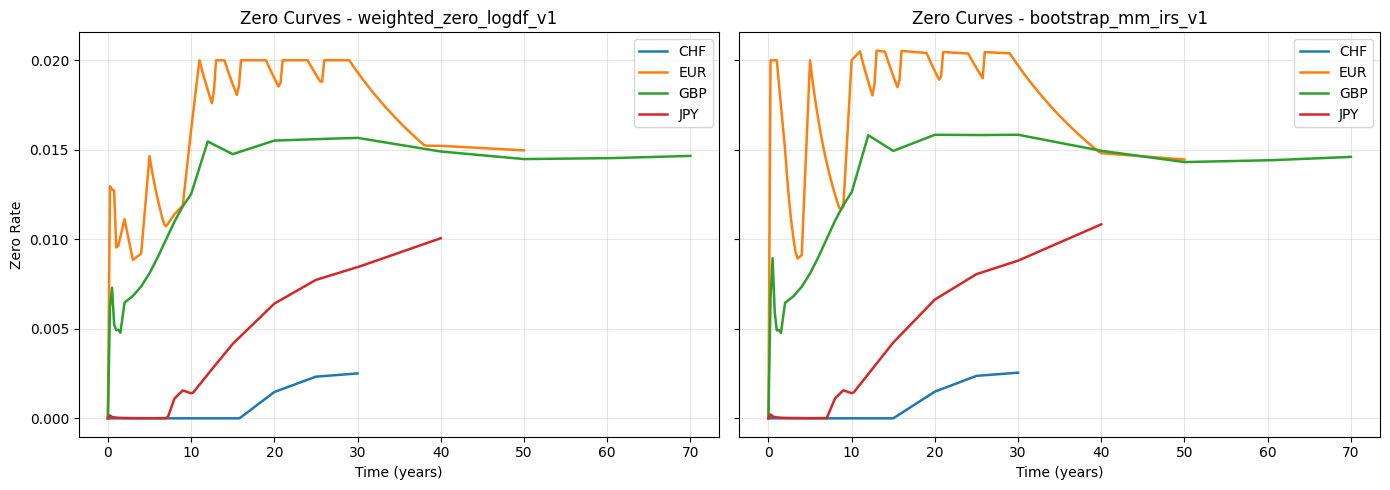

In [26]:
# 12) Plot zero curves explicitly: weighted vs bootstrap
sample_ccys = sorted(fitted.keys())[:4]  # keep chart readable

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Weighted method
ax = axes[0]
for ccy in sample_ccys:
    dense = fitted_dense_df[fitted_dense_df["ccy"] == ccy].sort_values("time")
    ax.plot(dense["time"], dense["zero_rate"], linewidth=1.8, label=ccy)
ax.set_title("Zero Curves - weighted_zero_logdf_v1")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Zero Rate")
ax.grid(True, alpha=0.3)
ax.legend()

# Bootstrap method
ax = axes[1]
for ccy in sample_ccys:
    dense = fitted_bootstrap_dense_df[fitted_bootstrap_dense_df["ccy"] == ccy].sort_values("time")
    ax.plot(dense["time"], dense["zero_rate"], linewidth=1.8, label=ccy)
ax.set_title("Zero Curves - bootstrap_mm_irs_v1")
ax.set_xlabel("Time (years)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# 13) Inspect one currency with calendar dates on dense grid (both methods)
sample_ccy = sorted(fitted_dense.keys())[0]
print("sample_ccy:", sample_ccy)

print("Weighted dense:")
display(
    fitted_dense_df[fitted_dense_df["ccy"] == sample_ccy][
        ["ccy", "asof_date", "time", "calendar_date", "df", "zero_rate", "curve_method"]
    ].head(20)
)

print("Bootstrap dense:")
display(
    fitted_bootstrap_dense_df[fitted_bootstrap_dense_df["ccy"] == sample_ccy][
        ["ccy", "asof_date", "time", "calendar_date", "df", "zero_rate", "curve_method"]
    ].head(20)
)

sample_ccy: CHF
Weighted dense:


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method
0,CHF,2016-02-05,0.00,2016-02-05,1.0,0.0,weighted_zero_logdf_v1
1,CHF,2016-02-05,0.25,2016-05-06,1.0,-0.0,weighted_zero_logdf_v1
2,CHF,2016-02-05,0.50,2016-08-05,1.0,-0.0,weighted_zero_logdf_v1
3,CHF,2016-02-05,0.75,2016-11-05,1.0,-0.0,weighted_zero_logdf_v1
4,CHF,2016-02-05,1.00,2017-02-04,1.0,-0.0,weighted_zero_logdf_v1
5,CHF,2016-02-05,1.25,2017-05-06,1.0,-0.0,weighted_zero_logdf_v1
6,CHF,2016-02-05,1.50,2017-08-06,1.0,-0.0,weighted_zero_logdf_v1
7,CHF,2016-02-05,1.75,2017-11-05,1.0,-0.0,weighted_zero_logdf_v1
8,CHF,2016-02-05,2.00,2018-02-04,1.0,-0.0,weighted_zero_logdf_v1
9,CHF,2016-02-05,2.25,2018-05-06,1.0,-0.0,weighted_zero_logdf_v1


Bootstrap dense:


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method
0,CHF,2016-02-05,0.00,2016-02-05,1.0,0.0,bootstrap_mm_irs_v1
1,CHF,2016-02-05,0.25,2016-05-06,1.0,-0.0,bootstrap_mm_irs_v1
2,CHF,2016-02-05,0.50,2016-08-05,1.0,-0.0,bootstrap_mm_irs_v1
3,CHF,2016-02-05,0.75,2016-11-05,1.0,-0.0,bootstrap_mm_irs_v1
4,CHF,2016-02-05,1.00,2017-02-04,1.0,-0.0,bootstrap_mm_irs_v1
5,CHF,2016-02-05,1.25,2017-05-06,1.0,0.0,bootstrap_mm_irs_v1
6,CHF,2016-02-05,1.50,2017-08-06,1.0,0.0,bootstrap_mm_irs_v1
7,CHF,2016-02-05,1.75,2017-11-05,1.0,0.0,bootstrap_mm_irs_v1
8,CHF,2016-02-05,2.00,2018-02-04,1.0,-0.0,bootstrap_mm_irs_v1
9,CHF,2016-02-05,2.25,2018-05-06,1.0,0.0,bootstrap_mm_irs_v1
